In [1]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt

from sango import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from sango.model import IN, LIF, PSP, pLIF

%load_ext autoreload
%autoreload 2

In [2]:
class Input(Network):
    def __init__(self, spike_times):
        super().__init__()
        self.spike_times = spike_times # n x t

    def build(self):
        self.spikegen = NodeGroup(IN(), len(self.spike_times), times=self.spike_times)
        
        return

In [3]:
# Helper function for edges
def get_rand_proj(prob, num_s, num_t):
    edges = set()
    assert 0.0 <= prob <= 1.0, f"Probability {prob} is not between 0.0 and 1.0"
    num = int(prob * num_s * num_t)
    while len(edges) < num:
        s = np.random.randint(num_s)
        t = np.random.randint(num_t)
        edges.add((s,t))
    return list(edges)

# Network that implements a dendritic structure
class dLIF(Network):
    def __init__(self, n_branch=20, n_leaf=10, prob=0.1):
        super().__init__()
        self.n_branch = n_branch
        self.n_leaf = n_leaf
        self.prob = prob
        self.input = NodePort()

    def build(self):
        # Main neuron
        self.soma = NodeGroup(pLIF(threshold=2.0, leak=0.1, prob=0.8))

        # Dendritic branches
        # Ideally, the model performs more than just addition,
        # but we just use the LIF model here for illustration
        self.dend = NodeGroup(LIF(threshold=1.0, leak=0.2), self.n_branch)
        self.leaf = [NodeGroup(LIF(threshold=0.9, leak=1.0), self.n_leaf) for _ in range(self.n_branch)]

        # Internal connections
        self.d_s = EdgeGroup(self.dend, self.soma, PSP(),
                             edges=[(i,0) for i in range(self.n_branch)])
        self.l_d = []
        for d in range(self.n_branch):      
            self.l_d.append(EdgeGroup(self.leaf[d], self.dend, PSP(),
                                      edges=[(i,d) for i in range(self.n_leaf)]))

        # Input Projection
        self.i_l = []
        for d in range(self.n_branch):
            proj_edges = get_rand_proj(self.prob, self.input.size, self.n_leaf)
            self.i_l.append(EdgeGroup(self.input, self.leaf[d], PSP(),
                                      edges=proj_edges))
        
        return

In [4]:
# Inputs
input_n = 32
input_t = 100
input_prob = 0.1

# Dense vector (just random 0s and 1s)
in_spikes = np.random.binomial(1, input_prob, (input_n, input_t))

# Sparse vector (only spike times)
in_n , in_t = np.where(in_spikes == 1)
in_times = [[] for _ in range(input_n)]
for n, t in zip(in_n, in_t):
    in_times[n].append(t)

In [5]:
net = Network()

n_branch = 20
n_leaf = 10

net.i = Input(in_times)
net.d = dLIF(n_branch, n_leaf)

net.connect(net.i.spikegen, net.d.input)

info: adding network i
info: adding network d


In [6]:
net.build()

info: building network i
info: linking port d.input
info: resolving dependency for d.input
info: building network d
info: adding empty list d.l_d
info: adding empty list d.i_l
info: flattening network topology


In [7]:
print(net)

(node) i.spikegen
(port) d.input <- (node) i.spikegen
(node) d.soma
(node) d.dend
(node) d.leaf[0]
(node) d.leaf[1]
(node) d.leaf[2]
(node) d.leaf[3]
(node) d.leaf[4]
(node) d.leaf[5]
(node) d.leaf[6]
(node) d.leaf[7]
(node) d.leaf[8]
(node) d.leaf[9]
(node) d.leaf[10]
(node) d.leaf[11]
(node) d.leaf[12]
(node) d.leaf[13]
(node) d.leaf[14]
(node) d.leaf[15]
(node) d.leaf[16]
(node) d.leaf[17]
(node) d.leaf[18]
(node) d.leaf[19]
(edge) d.d_s: (node) d.dend -> (node) d.soma
(edge) d.l_d[0]: (node) d.leaf[0] -> (node) d.dend
(edge) d.l_d[1]: (node) d.leaf[1] -> (node) d.dend
(edge) d.l_d[2]: (node) d.leaf[2] -> (node) d.dend
(edge) d.l_d[3]: (node) d.leaf[3] -> (node) d.dend
(edge) d.l_d[4]: (node) d.leaf[4] -> (node) d.dend
(edge) d.l_d[5]: (node) d.leaf[5] -> (node) d.dend
(edge) d.l_d[6]: (node) d.leaf[6] -> (node) d.dend
(edge) d.l_d[7]: (node) d.leaf[7] -> (node) d.dend
(edge) d.l_d[8]: (node) d.leaf[8] -> (node) d.dend
(edge) d.l_d[9]: (node) d.leaf[9] -> (node) d.dend
(edge) d.l_d[

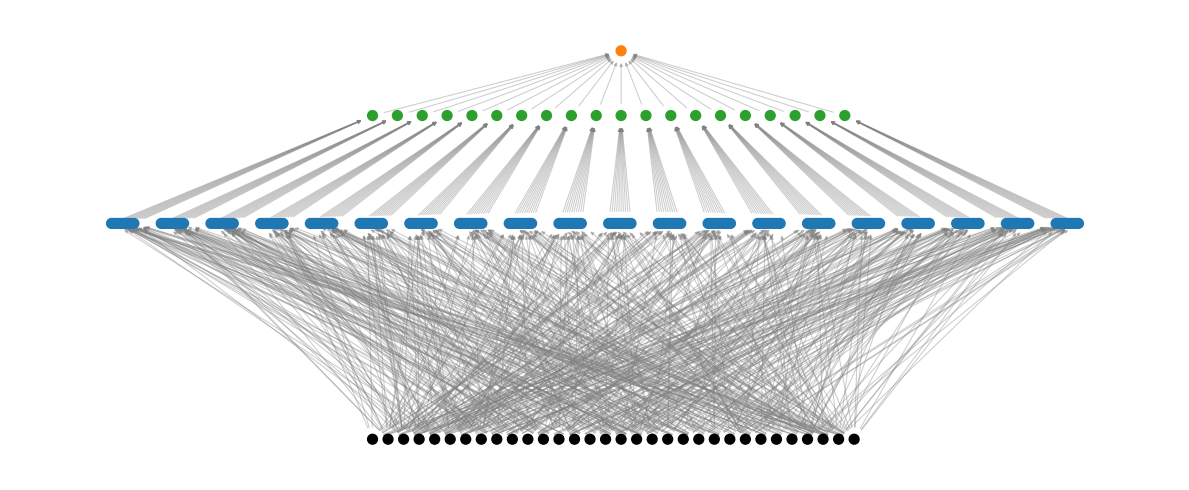

In [8]:
# Modify the positions a bit for the visualization
graph = net.graph()
pos = nx.circular_layout(graph)
index_map = {node: i for i, node in enumerate(graph.nodes())}
color_map = ['black' for node in graph.nodes()] # default

for i in range(input_n):
    pos[net.i.spikegen[i].name][0] = 1.0 * i / input_n - 0.5
    pos[net.i.spikegen[i].name][1] = 0.0
    
for i in range(n_branch):
    pos[net.d.dend[i].name][0] = 1.0 * i / n_branch - 0.5
    pos[net.d.dend[i].name][1] = 0.75
    color_map[index_map[net.d.dend[i].name]] = 'tab:green'
    for j in range(n_leaf):
        pos[net.d.leaf[i][j].name][0] = (2.0*i/n_branch - 1.0) + (1.0*j/n_leaf - 0.5)/(1.0*n_branch)
        pos[net.d.leaf[i][j].name][1] = 0.5
        color_map[index_map[net.d.leaf[i][j].name]] = 'tab:blue'

pos[net.d.soma[0].name][0] = 0.0
pos[net.d.soma[0].name][1] = 0.9
color_map[index_map[net.d.soma[0].name]] = 'tab:orange'

# Visualize
plt.figure(figsize=(12, 5))
nx.draw_networkx_nodes(graph, pos, node_size=50, node_color=color_map)
nx.draw_networkx_edges(graph, pos, edge_color='gray', alpha=0.4, width=0.75, arrowsize=5)

plt.axis('off')
plt.tight_layout()

In [9]:
class dNet(Network):
    def __init__(self, n_neuron, n_branch, n_leaf, prob):
        super().__init__()
        self.n_neuron = n_neuron
        self.n_branch = n_branch
        self.n_leaf = n_leaf
        self.prob = prob

    def build(self):
        # Neurons
        self.neuron = [dLIF(self.n_branch, self.n_leaf, self.prob) for _ in range(self.n_neuron)]

        self.somas = NodeList([self.neuron[i].soma[0] for i in range(self.n_neuron)])
        
        # Reservoir-like connectivity
        for i in range(self.n_neuron):
            self.connect(self.somas, self.neuron[i].input)

In [10]:
net = Network()

n_neuron = 30
n_branch = 20
n_leaf = 10
prob = 0.02

net.d = dNet(n_neuron, n_branch, n_leaf, prob)

info: adding network d


In [11]:
net.build()

info: building network d
info: adding list of networks d.neuron
info: linking port d.neuron[0].input
info: linking port d.neuron[1].input
info: linking port d.neuron[2].input
info: linking port d.neuron[3].input
info: linking port d.neuron[4].input
info: linking port d.neuron[5].input
info: linking port d.neuron[6].input
info: linking port d.neuron[7].input
info: linking port d.neuron[8].input
info: linking port d.neuron[9].input
info: linking port d.neuron[10].input
info: linking port d.neuron[11].input
info: linking port d.neuron[12].input
info: linking port d.neuron[13].input
info: linking port d.neuron[14].input
info: linking port d.neuron[15].input
info: linking port d.neuron[16].input
info: linking port d.neuron[17].input
info: linking port d.neuron[18].input
info: linking port d.neuron[19].input
info: linking port d.neuron[20].input
info: linking port d.neuron[21].input
info: linking port d.neuron[22].input
info: linking port d.neuron[23].input
info: linking port d.neuron[24].in

In [12]:
graph = net.graph()
print(graph.number_of_nodes())
print(graph.number_of_edges())

6630
10200


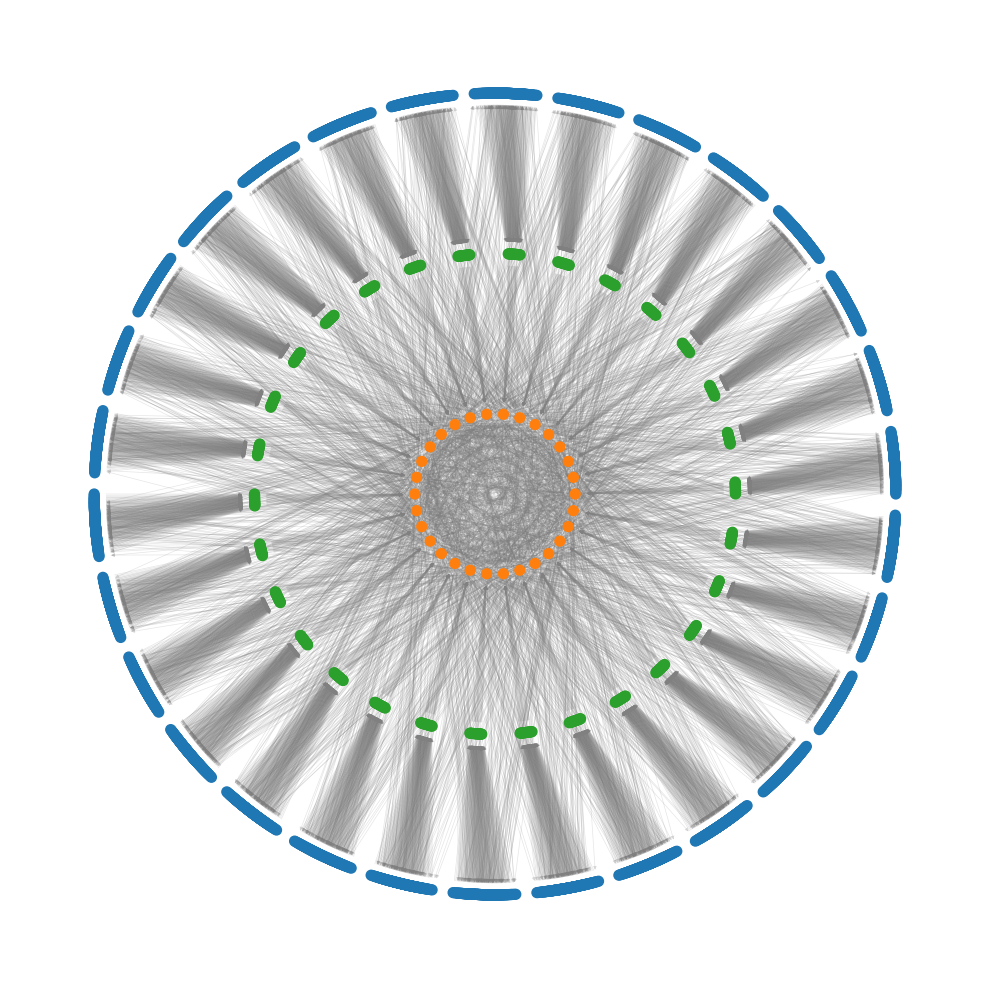

In [13]:
# Modify the positions a bit for the visualization
pos = nx.circular_layout(graph)
index_map = {node: i for i, node in enumerate(graph.nodes())}
color_map = ['black' for node in graph.nodes()] # default

# Each neuron gets its own arc
r_soma = 0.2
r_dend = 0.6
r_leaf = 1.0
for i in range(n_neuron):
    pos[net.d.neuron[i].soma[0].name][0] = r_soma * np.cos(2*np.pi*i/n_neuron)
    pos[net.d.neuron[i].soma[0].name][1] = r_soma * np.sin(2*np.pi*i/n_neuron)
    color_map[index_map[net.d.neuron[i].soma[0].name]] = 'tab:orange'
    for j in range(n_branch):
        pos[net.d.neuron[i].dend[j].name][0] = r_dend * np.cos(2*np.pi*i/n_neuron +
                                                               (0.5*np.pi/n_neuron)*j/n_branch)
        pos[net.d.neuron[i].dend[j].name][1] = r_dend * np.sin(2*np.pi*i/n_neuron +
                                                               (0.5*np.pi/n_neuron)*j/n_branch)
        color_map[index_map[net.d.neuron[i].dend[j].name]] = 'tab:green'
        for k in range(n_leaf):  
            pos[net.d.neuron[i].leaf[j][k].name][0] = r_leaf * np.cos(2*np.pi*i/n_neuron +
                                                                      (0.65*np.pi/n_neuron)*j/n_branch +
                                                                      (0.65*np.pi/n_branch)*k/n_leaf)
            pos[net.d.neuron[i].leaf[j][k].name][1] = r_leaf * np.sin(2*np.pi*i/n_neuron +
                                                                      (0.65*np.pi/n_neuron)*j/n_branch +
                                                                      (0.65*np.pi/n_branch)*k/n_leaf)
            color_map[index_map[net.d.neuron[i].leaf[j][k].name]] = 'tab:blue'

# Visualize
plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(graph, pos, node_size=50, node_color=color_map)
nx.draw_networkx_edges(graph, pos, edge_color='gray', alpha=0.2, width=0.5, arrowsize=5)

plt.axis('off')
plt.tight_layout()